# Fitting X-ray spectra with TORITO in Sherpa

This notebook shows, step by step, how to use TORITO, the interpolation model of
*Melazzini & Sazonov, "Interpolation Model For Fitting AGN X-Ray Spectra"* to fit the X-ray
spectrum of an obscured AGN with [Sherpa](https://sherpa.readthedocs.io).

The model describes an AGN seen through a **clumpy, Compton-thick torus**. It is an
interpolation over a grid of Monte Carlo spectra (0.1–300 keV) with five physical
parameters:

| parameter | meaning | range in the fit |
|---|---|---|
| `alpha` | viewing angle from the torus axis, in **degrees** | 60.1–79.9 |
| `nh` | line-of-sight column density, $10^{24}\,\mathrm{cm^{-2}}$ | 0.501–9.9 |
| `nha` | average column density of the torus, $10^{24}\,\mathrm{cm^{-2}}$ | 1.0–9.9 |
| `nav` | average number of clouds along the line of sight | 2–15.9 |
| `afe` | iron abundance relative to solar | 0.501–1.99 |

plus an overall normalization `norm` and a `redshift`. The primary continuum is fixed
($\Gamma = 1.8$, $E_\mathrm{cut} = 300$ keV) and so is the torus half-opening angle (60°).

**What you need**

* Python with `numpy`, `scipy`, `matplotlib` and Sherpa (standalone or from CIAO);
* the `torito` package (`pip install .` from the repository root);
* the grid file `torito_grid_v1.npz` (see the README for where to put it);
* for real data, a Sherpa with XSPEC support (e.g. the one in CIAO) if you want XSPEC
  absorption models such as `xstbabs`. This example itself does not need XSPEC.

The Sherpa model is `torito.sherpa_model.TorusModel`. It evaluates the grid on **any energy
binning** (for instance that of an instrument response) and at **any redshift**.

## 1. Setup

TORITO finds its grid through the `TORITO_GRID` environment variable or at
`~/.torito/torito_grid_v1.npz`. To use a file elsewhere, set `GRID` below to its path.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

GRID = None          # or "path/to/torito_grid_v1.npz"

%matplotlib inline

Loading the grid builds the interpolator over all 9468 spectra, which takes about a
minute. It only happens once per session; without this call, it would happen at the first
model evaluation.

In [2]:
from sherpa.astro import ui
import torito
from torito.sherpa_model import TorusModel

t0 = time.time()
torito.load_grid(GRID)
print(f"interpolator ready in {time.time() - t0:.0f} s")

ui.add_model(TorusModel)     # registers the Sherpa model type "torusmodel"

failed to import sherpa.image.ds9_backend due to 
'RuntimeErr: DS9Win unusable: Could not find ds9 on your PATH'


interpolator ready in 44 s


## 2. Creating a model component

Once registered, the model is used like any other Sherpa model. Its parameters come with
the bounds of the grid.

In [3]:
src = ui.create_model_component("torusmodel", "src")
print(src)

torusmodel.src
   Param        Type          Value          Min          Max      Units
   -----        ----          -----          ---          ---      -----
   src.norm     thawed            1            0        1e+10           
   src.alpha    thawed           70         60.1         79.9        deg
   src.nh       thawed            3        0.501          9.9 1e24 cm^-2
   src.nha      thawed            3            1          9.9 1e24 cm^-2
   src.nav      thawed            4            2         15.9           
   src.afe      thawed            1        0.501         1.99           
   src.redshift frozen            0            0           10           


## 3. What the model returns

Given the edges of a set of energy bins, the model returns the **number of photons in each
bin** (in arbitrary units, scaled by `norm`). Dividing by the bin width gives the photon
spectrum $dN/dE$; below we plot $E\,dN/dE$, which is how the grid itself is tabulated.

The helper `photon_spectrum` evaluates a component on a logarithmic grid of bins.

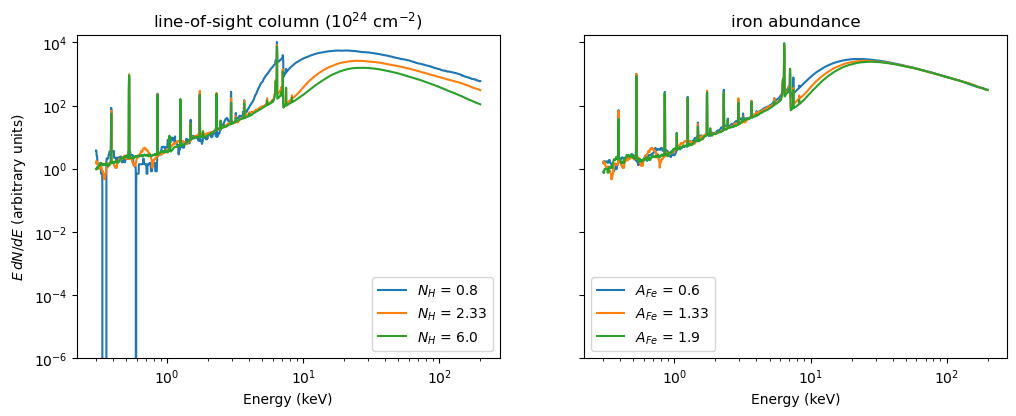

In [4]:
def photon_spectrum(component, emin=0.3, emax=200.0, nbins=2000):
    edges = np.geomspace(emin, emax, nbins + 1)
    lo, hi = edges[:-1], edges[1:]
    photons = component(lo, hi)            # photons per bin
    energy = np.sqrt(lo * hi)
    return energy, energy * photons / (hi - lo)   # E dN/dE

reference = dict(alpha=66.7, nh=2.33, nha=4.67, nav=3.35, afe=1.33, norm=1.0)

def set_pars(component, **values):
    for name, value in values.items():
        getattr(component, name).val = value

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for nh in (0.8, 2.33, 6.0):
    set_pars(src, **{**reference, "nh": nh})
    axes[0].loglog(*photon_spectrum(src), label=f"$N_H$ = {nh}")
for afe in (0.6, 1.33, 1.9):
    set_pars(src, **{**reference, "afe": afe})
    axes[1].loglog(*photon_spectrum(src), label=f"$A_{{Fe}}$ = {afe}")
for ax in axes:
    ax.set_xlabel("Energy (keV)")
    ax.set_ylim(1e-6, None)
    ax.legend()
axes[0].set_ylabel(r"$E\,dN/dE$ (arbitrary units)")
axes[0].set_title(r"line-of-sight column ($10^{24}$ cm$^{-2}$)")
axes[1].set_title("iron abundance")
set_pars(src, **reference)
plt.show()

## 4. Redshift

The `redshift` parameter shifts the whole spectrum; it is frozen by default, as it is
normally known. Here the Fe K$\alpha$ line moves from 6.4 keV to $6.4/(1+z)$.

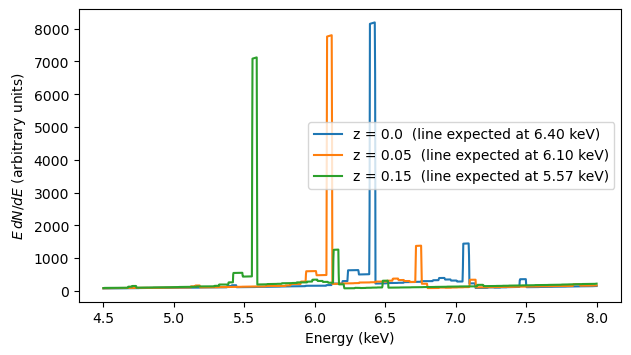

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.8))
for z in (0.0, 0.05, 0.15):
    src.redshift = z
    energy, spec = photon_spectrum(src, 4.5, 8.0, 1500)
    ax.plot(energy, spec, label=f"z = {z}  (line expected at {6.4 / (1 + z):.2f} keV)")
src.redshift = 0.0
ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E\,dN/dE$ (arbitrary units)")
ax.legend()
plt.show()

## 5. An observation to fit

With real data you would simply call `ui.load_pha("spectrum.pha")`, which also loads the
response (RMF, ARF) and the background; see Section 9.

To keep this notebook self-contained we **simulate** an observation instead: an idealized
NuSTAR-like response covering 3–79 keV in 40 eV channels, a source with the parameters
below at $z = 0.02$, and an exposure that gives about $2.5\times10^4$ counts, the photon
statistics used in the paper.

In [6]:
from sherpa.astro.instrument import create_arf, create_delta_rmf

channel_edges = np.arange(3.0, 79.0 + 1e-9, 0.04)
elo, ehi = channel_edges[:-1], channel_edges[1:]
rmf = create_delta_rmf(elo, ehi, e_min=elo, e_max=ehi)   # ideal energy resolution
arf = create_arf(elo, ehi, np.full(elo.size, 100.0))       # flat effective area, cm^2

truth = dict(alpha=66.7, nh=2.33, nha=4.67, nav=3.35, afe=1.33, norm=1.0)

ui.dataspace1d(1, elo.size, id=1, dstype=ui.DataPHA)
ui.set_rmf(1, rmf)
ui.set_arf(1, arf)
ui.set_source(1, src)
set_pars(src, **truth)
src.redshift = 0.02

# pick the exposure that gives ~2.5e4 counts, then simulate with Poisson noise
ui.set_exposure(1, 1.0)
expected_per_unit_time = ui.get_model_plot(1).y.sum() * 0.04
exposure = 2.5e4 / expected_per_unit_time
np.random.seed(42)
ui.fake_pha(1, arf=arf, rmf=rmf, exposure=exposure)

data = ui.get_data(1)
print(f"simulated counts: {data.counts.sum():.0f} in {data.counts.size} channels")

simulated counts: 25049 in 1900 channels


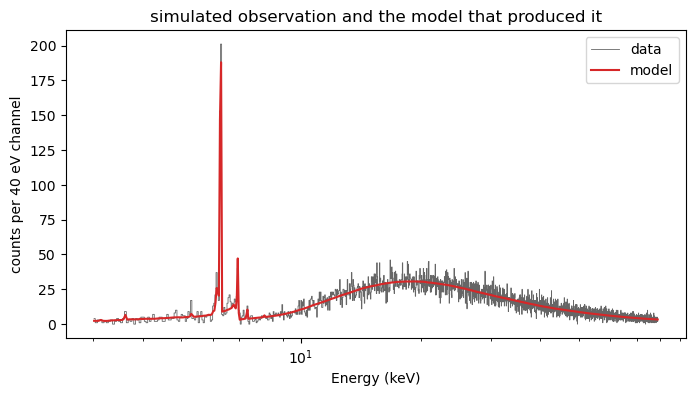

In [7]:
def plot_counts(title, with_model=True):
    fig, ax = plt.subplots(figsize=(8, 4))
    centre = 0.5 * (elo + ehi)
    ax.step(centre, ui.get_data(1).counts, where="mid", lw=0.6, color="0.4", label="data")
    if with_model:
        model_counts = ui.get_model_plot(1).y * 0.04 * ui.get_exposure(1)
        ax.plot(centre, model_counts, color="C3", lw=1.5, label="model")
    ax.set_xscale("log")
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("counts per 40 eV channel")
    ax.set_title(title)
    ax.legend()
    plt.show()

plot_counts("simulated observation and the model that produced it")

## 6. Fitting

Use the **Cash statistic** (`cstat`): most channels contain only a few counts.

Use a **global optimizer**. The interpolated model is piecewise linear and not smooth
across the nodes of the grid, and its parameters are partly degenerate, so the statistic
has local minima in which local optimizers (`levmar`, `neldermead`) can get stuck. With
this very spectrum, `neldermead` started from three random points ends about 37 units of
`cstat` above the true parameters, at $N_H \simeq 6.6$ instead of 2.33. The paper uses
`moncar`, a differential-evolution optimizer, which finds the right minimum here in a few
minutes.

In [8]:
ui.set_stat("cstat")
ui.set_method("moncar")

free = ["alpha", "nh", "nha", "nav", "afe"]
rng = np.random.default_rng(1)
for name in free:                                   # a random start inside the bounds
    par = getattr(src, name)
    par.val = rng.uniform(par.min, par.max)
src.norm.val = 1.0

t0 = time.time()
ui.fit(1)
best = ui.get_fit_results()
print(f"\n{time.time() - t0:.0f} s; cstat = {best.statval:.1f} for {best.dof} degrees of freedom")

Dataset               = 1
Method                = moncar
Statistic             = cstat
Initial fit statistic = 2.97735e+06
Final fit statistic   = 1898.77 at function evaluation 10368
Data points           = 1900
Degrees of freedom    = 1894
Probability [Q-value] = 0.46484
Reduced statistic     = 1.00252
Change in statistic   = 2.97545e+06
   src.norm       0.879059    
   src.alpha      65.2605     
   src.nh         2.10139     
   src.nha        3.55776     
   src.nav        4           
   src.afe        1.5419      



256 s; cstat = 1898.8 for 1894 degrees of freedom


Because this spectrum is simulated, we can check the result against the true parameters:
the fit should reach a statistic at least as low as that of the truth. Individual values
differ from the truth by the statistical scatter expected for $2.5\times10^4$ counts
(Section 6 of the paper), which is larger here because only the 3–79 keV band is used.
Fitted values may also settle exactly on a grid node, a consequence of the piecewise-linear
interpolation.

cstat: best fit 1898.8, true parameters 1902.3

parameter      true   fitted
norm          1.000    0.879
alpha        66.700   65.260
nh            2.330    2.101
nha           4.670    3.558
nav           3.350    4.000
afe           1.330    1.542


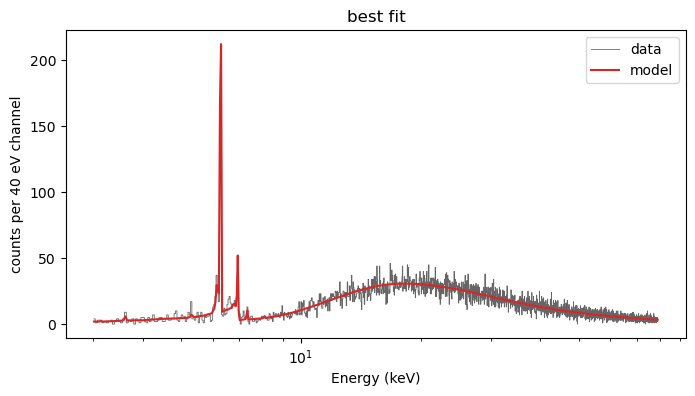

In [9]:
fitted = {name: getattr(src, name).val for name in ["norm"] + free}
set_pars(src, **truth)
stat_truth = ui.calc_stat(1)
set_pars(src, **fitted)
print(f"cstat: best fit {ui.calc_stat(1):.1f}, true parameters {stat_truth:.1f}\n")

print(f"{'parameter':10} {'true':>8} {'fitted':>8}")
for name in ["norm"] + free:
    print(f"{name:10} {truth[name]:8.3f} {fitted[name]:8.3f}")

plot_counts("best fit")

## 7. Is the result inside the trusted region of the grid?

The grid is not equally reliable everywhere (Section 2.4 of the paper):

* at a given $\langle N_H \rangle$, some line-of-sight columns are photon-starved in the
  underlying simulations;
* above $\langle N_C \rangle = 8$ the only grid spectra are those of the smooth torus, which
  exist only where $N_H = \langle N_H \rangle$.

**The fit does not enforce these limits**, so check the result yourself.

In [10]:
issues = torito.trusted_region_issues(src.nh.val, src.nha.val, src.nav.val)
print("best fit:", "inside the trusted region" if not issues else issues)

# two examples that would need caution
print(torito.trusted_region_issues(nh=9.0, nha=1.5, nav=4.0))
print(torito.trusted_region_issues(nh=2.0, nha=6.0, nav=12.0))

best fit: inside the trusted region
['N_H = 9 is outside the usable range 0.5-3.25 (1e24 cm^-2) for <N_H> = 1.5']
['<N_c> = 12 > 8 is only supported where N_H = <N_H>, but N_H = 2 and <N_H> = 6']


## 8. Parameter uncertainties

Sherpa's `conf` and `covar` assume a smooth, well-behaved statistic surface, which this
model does not guarantee. The paper instead estimates uncertainties by **Poisson
resampling**: simulate many spectra from the best-fit model, refit each of them with the
same procedure, and take the scatter of the fitted values.

Below we do this with only 10 realizations to keep it fast. In practice, about 100
realizations are enough for the standard deviations and for 2D scatter plots of pairs of
parameters showing their correlation; well-sampled 95 per cent contours need of order
1000. Each refit starts from the best fit and uses `neldermead` for speed,
which is reasonable once `moncar` has found the global minimum; refitting every
realization with `moncar` is the safer choice when time allows.

In [11]:
ui.set_method("neldermead")
best_values = dict(fitted)
observed = ui.get_data(1).counts.copy()
model_counts = ui.get_model_plot(1).y * 0.04 * ui.get_exposure(1)

samples = []
t0 = time.time()
for i in range(10):
    ui.set_dep(1, np.random.poisson(model_counts))
    set_pars(src, **best_values)
    ui.fit(1)
    samples.append([getattr(src, name).val for name in ["norm"] + free])
samples = np.array(samples)

ui.set_dep(1, observed)                 # put the observation back
set_pars(src, **best_values)

print(f"{time.time() - t0:.0f} s\n")
print(f"{'parameter':10} {'best fit':>9} {'scatter':>9}")
for name, column in zip(["norm"] + free, samples.T):
    print(f"{name:10} {best_values[name]:9.3f} {column.std(ddof=1):9.3f}")

Dataset               = 1
Method                = neldermead
Statistic             = cstat
Initial fit statistic = 1914.12
Final fit statistic   = 1903.72 at function evaluation 1297
Data points           = 1900
Degrees of freedom    = 1894
Probability [Q-value] = 0.433075
Reduced statistic     = 1.00513
Change in statistic   = 10.3938
   src.norm       0.885634    
   src.alpha      64.3706     
   src.nh         2.23948     
   src.nha        3.26785     
   src.nav        5           
   src.afe        1.57372     


Dataset               = 1
Method                = neldermead
Statistic             = cstat
Initial fit statistic = 1976.65
Final fit statistic   = 1964.2 at function evaluation 886
Data points           = 1900
Degrees of freedom    = 1894
Probability [Q-value] = 0.127639
Reduced statistic     = 1.03707
Change in statistic   = 12.4479
   src.norm       0.926979    
   src.alpha      66.0606     
   src.nh         2.30058     
   src.nha        3.52761     
   src.nav        3.52762     
   src.afe        1.43117     


Dataset               = 1
Method                = neldermead
Statistic             = cstat
Initial fit statistic = 1938.95
Final fit statistic   = 1930.61 at function evaluation 832
Data points           = 1900
Degrees of freedom    = 1894
Probability [Q-value] = 0.27364
Reduced statistic     = 1.01933
Change in statistic   = 8.34134
   src.norm       0.860997    
   src.alpha      64.1912     
   src.nh         2.05736     
   src.nha        3.63802     
   src.nav        4.1404      
   src.afe        1.65761     


Dataset               = 1
Method                = neldermead
Statistic             = cstat
Initial fit statistic = 1952.08
Final fit statistic   = 1947.93 at function evaluation 780
Data points           = 1900
Degrees of freedom    = 1894
Probability [Q-value] = 0.189719
Reduced statistic     = 1.02848
Change in statistic   = 4.1476
   src.norm       0.884691    
   src.alpha      65.0166     
   src.nh         2.1499      
   src.nha        3.44989     
   src.nav        4.46427     
   src.afe        1.57528     


Dataset               = 1
Method                = neldermead
Statistic             = cstat
Initial fit statistic = 2050.96
Final fit statistic   = 2048.74 at function evaluation 1436
Data points           = 1900
Degrees of freedom    = 1894
Probability [Q-value] = 0.00695418
Reduced statistic     = 1.0817
Change in statistic   = 2.21614
   src.norm       0.919741    
   src.alpha      66.3607     
   src.nh         2.25893     
   src.nha        3.59844     
   src.nav        3.48804     
   src.afe        1.46725     


...

Dataset               = 1
Method                = neldermead
Statistic             = cstat
Initial fit statistic = 1929.64
Final fit statistic   = 1926.68 at function evaluation 813
Data points           = 1900
Degrees of freedom    = 1894
Probability [Q-value] = 0.295042
Reduced statistic     = 1.01725
Change in statistic   = 2.9614
   src.norm       0.876735    
   src.alpha      64.8        
   src.nh         2.04382     
   src.nha        3.6933      
   src.nav        3.86732     
   src.afe        1.61982     


Dataset               = 1
Method                = neldermead
Statistic             = cstat
Initial fit statistic = 1933.94
Final fit statistic   = 1928.26 at function evaluation 939
Data points           = 1900
Degrees of freedom    = 1894
Probability [Q-value] = 0.286327
Reduced statistic     = 1.01809
Change in statistic   = 5.68215
   src.norm       0.851305    
   src.alpha      65.0984     
   src.nh         1.92943     
   src.nha        3.77322     
   src.nav        4.00117     
   src.afe        1.70566     


Dataset               = 1
Method                = neldermead
Statistic             = cstat
Initial fit statistic = 1958.35
Final fit statistic   = 1952.69 at function evaluation 1248
Data points           = 1900
Degrees of freedom    = 1894
Probability [Q-value] = 0.16986
Reduced statistic     = 1.03099
Change in statistic   = 5.6597
   src.norm       0.869642    
   src.alpha      64.9435     
   src.nh         2.13875     
   src.nha        3.47418     
   src.nav        4           
   src.afe        1.49213     


Dataset               = 1
Method                = neldermead
Statistic             = cstat
Initial fit statistic = 1908.75
Final fit statistic   = 1906.25 at function evaluation 1247
Data points           = 1900
Degrees of freedom    = 1894
Probability [Q-value] = 0.417061
Reduced statistic     = 1.00647
Change in statistic   = 2.49609
   src.norm       0.898432    
   src.alpha      65.8974     
   src.nh         2.16245     
   src.nha        3.41028     
   src.nav        3.91511     
   src.afe        1.52122     


232 s

parameter   best fit   scatter
norm           0.879     0.024
alpha         65.260     0.768
nh             2.101     0.111
nha            3.558     0.149
nav            4.000     0.439
afe            1.542     0.088


## 9. With a real spectrum

The same steps apply to real data. A typical session looks like this (not run here: it
needs your own files and, for `xstbabs`, Sherpa with XSPEC):

```python
ui.load_pha("nustar_fpma.pha")           # loads RMF, ARF and background as well
ui.subtract()                             # or model the background instead
ui.notice(3.0, 79.0)
ui.group_counts(1)                        # optional; cstat works on ungrouped data

src = ui.create_model_component("torusmodel", "src")
gal = ui.create_model_component("xstbabs", "gal")        # Galactic absorption
scat = ui.create_model_component("powlaw1d", "scat")     # scattered, unabsorbed power law
scat.gamma = 1.8
scat.gamma.freeze()

ui.set_source(gal * (src + scat))
gal.nh = 0.05                             # 10^22 cm^-2, frozen at the Galactic value
gal.nh.freeze()
src.redshift = 0.0165                     # frozen at the known redshift

ui.set_stat("cstat")
ui.set_method("moncar")
ui.fit()
```

Several instruments (e.g. NuSTAR FPMA/FPMB and XMM-Newton) are fitted together by loading
each spectrum with its own id and sharing the source model, with a free cross-calibration
constant per instrument.

## 10. Things to keep in mind

* **Viewing angle in degrees.** `alpha` is given in degrees and covers 60.1°–79.9°.
* **Fixed continuum and geometry.** $\Gamma = 1.8$, $E_\mathrm{cut} = 300$ keV and the
  half-opening angle of 60° are built into the grid.
* **Normalization.** `norm` has arbitrary units: it scales photons per bin of a spectrum
  normalized as described in Section 2.3 of the paper.
* **Trusted region.** Check every result with `torito.trusted_region_issues` (Section 7).
* **Optimizer.** Use `moncar` (or several starts of it): local optimizers can stop in a
  local minimum far from the truth (Section 6).
* **Speed.** The interpolator is built once per session (about a minute); each model
  evaluation afterwards is fast.
* **Energy range.** Outside 0.1–300 keV (in the rest frame) the model returns no photons.